# EDA — NCTB Class 9–10 Science Corpus

**Project:** chapter-grounded science tutor over NCTB Physics, Chemistry, Biology (class 9–10)  
**Data speciality:** Bangla (conjuncts, matras, Bangla–Latin code-mixing, figure-embedded labels)  
**Primary NFR:** auditable — 100% of answers replayable

This notebook produces every number quoted in Sections 2 and 3 of the A1 form.

**How it is designed to run.** OCR over ~900 pages takes hours, which would break the
"runs top-to-bottom without errors" requirement. So every expensive stage writes a cache to
`data/interim/`, and each cell loads the cache if it exists. First run: slow, and you may run
the OCR cell overnight. Every run after that: seconds.

**Reproducibility.** One seed, set once, used everywhere. The split is written to
`data/splits.json` so it is a fact on record rather than something recomputed each run —
our auditability NFR requires the corpus partition itself to be replayable.


## 0 · Setup

Config lives in one cell so a marker can see every knob in one place, and so nothing
downstream contains a hardcoded magic number.


In [2]:
import json, os, re, random, hashlib, unicodedata
from pathlib import Path
from collections import defaultdict, Counter

import fitz                      # PyMuPDF — reads PDFs, rasterises pages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# ---- The one seed. Everything stochastic derives from this. ----------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ---- Paths. Relative, so the notebook runs on any machine. ----------------
ROOT     = Path('..') if Path('../data').exists() else Path('.')
RAW      = ROOT / 'data' / 'raw'          # the NCTB PDFs (never committed — link-only licence)
INTERIM  = ROOT / 'data' / 'interim'      # caches: page images, OCR text
PAGES    = INTERIM / 'pages'              # rasterised PNGs
OCR_DIR  = INTERIM / 'ocr'                # one .txt per page
FIGS     = ROOT / 'reports' / 'figures'   # plots + the three example pages for Section 3
for d in (INTERIM, PAGES, OCR_DIR, FIGS):
    d.mkdir(parents=True, exist_ok=True)

# ---- Corpus definition. Edit the filenames to match your downloads. -------
# 'edition' is pinned per book: NCTB revises page numbering between editions, and every
# citation our agent emits is page-anchored, so an unpinned edition = unreproducible answers.
BOOKS = [
    {'book_id': 'phy', 'subject': 'physics',   'file': 'physics_9_10.pdf',   'edition': '2026'},
    {'book_id': 'chem','subject': 'chemistry', 'file': 'chemistry_9_10.pdf', 'edition': '2026'},
    {'book_id': 'bio', 'subject': 'biology',   'file': 'biology_9_10.pdf',   'edition': '2026'},
]

# ---- Knobs, all justified in the form ------------------------------------
DPI          = 300     # vector source, so not capped by a native scan resolution;
            # 300 is a starting value — §7 ablation decides the final number
OCR_LANG     = 'ben+eng'   # Bengali traineddata. 'ben+eng' once we handle code-mixed formula lines
BLANK_INK    = 0.005   # <0.5% dark pixels ⇒ treat page as blank
RATIOS       = {'train': 0.70, 'val': 0.10, 'test': 0.20}

pd.set_option('display.width', 120)
print(f'seed={SEED}  dpi={DPI}  lang={OCR_LANG}')
print('raw exists:', RAW.exists(), '| books listed:', len(BOOKS))


seed=42  dpi=300  lang=ben+eng
raw exists: True | books listed: 3


## 1 · The PDFs are image-based, not pre-typed text

**Fills:** Section 2 → *Corpus name and link* (the scanned-page-images evidence).

This is the single most load-bearing check in the notebook. The whole project rests on
reading being a vision problem: if these PDFs carried a text layer, OCR would be trivial,
the Bangla speciality would collapse, and a marker would notice immediately.

Two independent signals, because either alone is weak:

1. **Text-layer extraction returns ~0 characters.** A born-digital PDF stores glyphs and
   returns thousands of characters per page. A scan returns nothing.
2. **Each page holds one full-page embedded raster.** This also gives us the *native*
   resolution of the scan — which caps how much detail rasterising can recover. Rendering
   at 600 DPI cannot invent detail the scanner never captured.


In [3]:
rows = []
for b in BOOKS:
    path = RAW / b['file']
    if not path.exists():
        print(f"MISSING: {path} — run scripts/get_data.sh first"); continue

    doc = fitz.open(path)
    # Sample evenly across the book rather than the first N pages: front matter is
    # atypical (it is often the only vector-text page in the whole file).
    idx = np.linspace(0, len(doc) - 1, min(20, len(doc))).astype(int)

    for i in idx:
        page = doc[int(i)]
        chars = len(page.get_text().strip())     # signal 1: text layer size
        imgs  = page.get_images(full=True)       # signal 2: embedded rasters
        # xref is the PDF object id; extract_image gives us the true stored pixel size
        native = ''
        if imgs:
            info = doc.extract_image(imgs[0][0])
            native = f"{info['width']}x{info['height']}"
        rows.append({'book': b['book_id'], 'page': int(i) + 1,
                     'text_layer_chars': chars, 'n_images': len(imgs),
                     'native_px': native})
    doc.close()

probe = pd.DataFrame(rows)
display(probe.groupby('book').agg(sampled_pages=('page', 'count'),
                                  mean_text_chars=('text_layer_chars', 'mean'),
                                  max_text_chars=('text_layer_chars', 'max'),
                                  mean_imgs_per_page=('n_images', 'mean')).round(2))
print('\nNative resolution of embedded scans (sample):')
print(probe['native_px'].value_counts().head())
print('\nVERDICT: text-layer chars ~0 and one full-page raster per page'
      ' => image-based scans. OCR is required, not optional.')


,sampled_pages,mean_text_chars,max_text_chars,mean_imgs_per_page
book,,,,
bio,20,0.00,0,1.1
chem,20,0.00,0,1.2
phy,20,0.35,4,1.3



Native resolution of embedded scans (sample):
native_px
           17
38x38       6
37x37       4
36x36       3
525x551     1
Name: count, dtype: int64

VERDICT: text-layer chars ~0 and one full-page raster per page => image-based scans. OCR is required, not optional.


## 2 · Corpus size

**Fills:** Section 2 → *How big is it* (pages, MB). The word count comes later, in §5,
because "usable text" means post-OCR text — counting anything else would be dishonest.

The A1 floor is ≥300 pages **and** ≥60,000 words. 


In [4]:
size_rows = []
for b in BOOKS:
    path = RAW / b['file']
    if not path.exists(): continue
    doc = fitz.open(path)
    size_rows.append({'book_id': b['book_id'], 'subject': b['subject'],
                      'edition': b['edition'], 'pages': len(doc),
                      'MB': round(path.stat().st_size / 1e6, 1)})
    doc.close()

sizes = pd.DataFrame(size_rows)
display(sizes)
total_pages = int(sizes['pages'].sum())
print(f"TOTAL: {total_pages} pages · {sizes['MB'].sum():.1f} MB")
print(f"Page floor (>=300): {'PASS' if total_pages >= 300 else 'FAIL — add a book'}")


,book_id,subject,edition,pages,MB
0,phy,physics,2026,366,106.4
1,chem,chemistry,2026,310,102.9
2,bio,biology,2026,326,107.8


TOTAL: 1002 pages · 317.1 MB
Page floor (>=300): PASS


## 3 · Rasterise pages to PNG

**Fills:** Section 2 → preparation table, *Rasterization* row.

The pages are already images *inside* a PDF container, but OCR and OpenCV need pixel
arrays, not PDF objects. Rasterising unwraps each page to a PNG.


Cached: pages already on disk are skipped, so reruns cost nothing.


In [5]:
def rasterise(book, dpi=DPI, overwrite=False):
    """PDF pages -> data/interim/pages/<book_id>_pNNNN.png. Returns paths."""
    path = RAW / book['file']
    if not path.exists(): return []
    out, doc = [], fitz.open(path)
    for i in range(len(doc)):
        png = PAGES / f"{book['book_id']}_p{i+1:04d}.png"
        if overwrite or not png.exists():
            # get_pixmap renders the page; colorspace GRAY halves size and OCR does not
            # use colour. Keep RGB only if you plan to analyse figure colour.
            doc[i].get_pixmap(dpi=dpi, colorspace=fitz.csGRAY).save(png)
        out.append(png)
    doc.close()
    return out

page_paths = {}
for b in BOOKS:
    page_paths[b['book_id']] = rasterise(b)
    print(f"{b['book_id']}: {len(page_paths[b['book_id']])} pages rendered @ {DPI} dpi")

png_mb = sum(p.stat().st_size for ps in page_paths.values() for p in ps) / 1e6
print(f'Rasterised corpus on disk: {png_mb:.1f} MB')


phy: 366 pages rendered @ 300 dpi
chem: 310 pages rendered @ 300 dpi
bio: 326 pages rendered @ 300 dpi
Rasterised corpus on disk: 310.5 MB


## 4 · Drop blank and non-content pages

**Fills:** Section 2 → preparation table, *Remove blank or non-content pages* row.

Blank versos, the imprint page, and the index are not answerable content. Leaving them in
inflates the page count and — worse — they become retrievable chunks that can win a
similarity match on sparse text and return a citation to a page with no information on it.

We drop them **before** splitting, so they cannot create false cross-split duplicate matches
in the leakage check (§9).

Detection is deliberately crude: fraction of dark pixels. A threshold is a decision, so we
plot the distribution and pick a cut where the histogram is genuinely bimodal rather than
trusting the default.


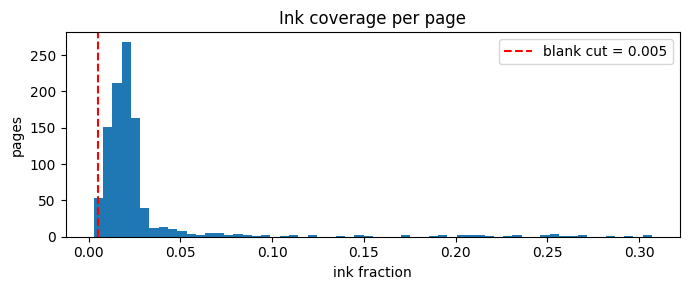

Blank/near-blank: 12 of 1002 pages (1.2%)
Examples: ['bio_p0164.png', 'bio_p0208.png', 'bio_p0258.png', 'bio_p0309.png', 'bio_p0325.png', 'chem_p0072.png', 'phy_p0100.png', 'phy_p0163.png']
EFFECT: corpus 1002 -> 990 content pages


In [6]:
def ink_fraction(png_path):
    """Fraction of pixels darker than mid-grey. Downsampled — we need a ratio, not detail."""
    im = Image.open(png_path).convert('L').resize((300, 400))
    return float((np.asarray(im) < 128).mean())

ink_cache = INTERIM / 'ink.json'
if ink_cache.exists():
    ink = json.loads(ink_cache.read_text())
else:
    ink = {p.name: ink_fraction(p) for ps in page_paths.values() for p in ps}
    ink_cache.write_text(json.dumps(ink))

vals = np.array(list(ink.values()))
plt.figure(figsize=(7, 3))
plt.hist(vals, bins=60)
plt.axvline(BLANK_INK, color='r', ls='--', label=f'blank cut = {BLANK_INK}')
plt.xlabel('ink fraction'); plt.ylabel('pages'); plt.legend()
plt.title('Ink coverage per page'); plt.tight_layout()
plt.savefig(FIGS / 'ink_distribution.png', dpi=150); plt.show()

blanks = sorted(n for n, v in ink.items() if v < BLANK_INK)
print(f'Blank/near-blank: {len(blanks)} of {len(ink)} pages ({100*len(blanks)/len(ink):.1f}%)')
print('Examples:', blanks[:8])
print(f'EFFECT: corpus {len(ink)} -> {len(ink)-len(blanks)} content pages')


## 5 · OCR — the expensive stage

**Fills:** Section 2 → *How big is it* (word count), and the raw material for everything below.

**Run this once.** Roughly 1–3 s per page, so ~900 pages is 20–45 minutes. Results cache to
`data/interim/ocr/`, one `.txt` per page, and reruns skip everything already done. If it dies
midway, rerun — it resumes.

`--psm 6` tells Tesseract to assume a single uniform block of text. NCTB body text is
single-column, so this beats the default page-segmentation mode, which tries to detect
columns and gets confused by figures. Figure-embedded labels are a known failure here and
are exactly why Stage 2 (layout) is core for us — we surface that in §6 rather than hiding it.


In [7]:
import pytesseract
# Windows users: point at the binary explicitly, e.g.
# pytesseract.pytesseract.tesseract_cmd = r'C:\\Program Files\\Tesseract-OCR\\tesseract.exe'
print('tesseract', pytesseract.get_tesseract_version())
assert 'ben' in pytesseract.get_languages(), \
    'Bengali traineddata missing: sudo apt install tesseract-ocr-ben'


tesseract 5.3.4


In [8]:
# ---- Which subject to OCR this run. Set to None to do all. ----
ONLY_BOOK = None          # 'phy' | 'chem' | 'bio' | None

def ocr_page(png_path, lang=OCR_LANG, psm=6):
    """OCR one page, caching to disk. Returns text."""
    cached = OCR_DIR / (png_path.stem + '.txt')
    if cached.exists():
        return cached.read_text(encoding='utf-8')
    txt = pytesseract.image_to_string(Image.open(png_path), lang=lang,
                                      config=f'--psm {psm}')
    cached.write_text(txt, encoding='utf-8')
    return txt

# Build the queue, optionally restricted to one book
todo = [p for book_id, ps in page_paths.items()
        if ONLY_BOOK is None or book_id == ONLY_BOOK
        for p in ps
        if ink.get(p.name, 1) >= BLANK_INK]

print(f'OCR queue: {len(todo)} content pages'
      f'{" (book=" + ONLY_BOOK + ")" if ONLY_BOOK else " (all books)"}')

for i, p in enumerate(todo, 1):
    ocr_page(p)
    if i % 50 == 0 or i == len(todo):
        print(f'  {i}/{len(todo)}', flush=True)
print('OCR complete (cached in data/interim/ocr/)')

OCR queue: 990 content pages (all books)
  50/990
  100/990
  150/990
  200/990
  250/990
  300/990
  350/990
  400/990
  450/990
  500/990
  550/990
  600/990
  650/990
  700/990
  750/990
  800/990
  850/990
  900/990
  950/990
  990/990
OCR complete (cached in data/interim/ocr/)


In [9]:
# Spot-check a few Physics pages, including a hard one
for stem in ['chem_p0261']:
    f = OCR_DIR / f'{stem}.txt'
    if f.exists():
        print(f'\n===== {stem} =====')
        print(f.read_text(encoding='utf-8')[:])


===== chem_p0261 =====
২৫৬ রসায়ন
ধাপ 1: প্রথমে একটি plaice সালফার (5) এবং শুষ্ক বায়ু (যে বায়ুতে জলীয় বাষ্প নেই) প্রবাহিত
করা হয়। এই চুল্লিতে সালফার এবং অক্সিজেন বিক্রিয়া করে সালফার ডাই-অক্মাইড উৎপন্ন করে।
S+0, —— SO,
ধাপ 2: SO, গ্যাসের সাথে কিছু 02 গ্যাস একটি চুল্লিতে প্রেরণ করা হয়। এই plas তাপমাত্রা থাকে
450°C _ 550°C এবং প্রভাবক থাকে ভ্যানাডিয়াম পেন্টা-অক্মাইড। এই চুল্লিতে উচ্চ তাপমাত্রায়
প্রভাবকের উপস্থিতিতে SO, এবং O, বিক্রিয়া করে সালফার ট্রাই-অক্সাইড উৎপন্ন করে।
2502 +O, ———+» 2503

ধাপ 3: উৎপন্ন SO, এর সাথে 720 এর সংস্পর্শ ঘটলে 77250, তৈরি হবে। কিন্তু so, এর সাথে
সরাসরি HO বিক্রিয়ায় বাষ্পীয় 72504 তৈরি হয় যা ঘন কুয়াশার মতো অবস্থা তৈরি করে। এতে
শিল্পকারখানায় কাজের অসুবিধা হয়। এছাড়া এই AMAR 2504 কে ঘনীভূত করে তরল 2504 এ
পরিণত করা কঠিন। এজন্য 503 কে প্রথমে গাঢ় 72504 এর মধ্যে শোষণ করিয়ে ধুমায়মান
সালফিউরিক এসিড তৈরি করা হয়। (ধূমায়মান সালফিউরিক এসিডকে অলিয়াম বলে। এর সংকেত
H,S,071)

H,SO, + SO; .—————> H,S,0,
ধূমায়মান সালফিউরিক এসিড এর সাথে পানির বিক্রিয়া ঘটিয়

### 5b · Normalise the extracted text

**Fills:** Section 2 → preparation table, *Normalise the extracted text* row.

This row is not a formality for Bangla. The same visible conjunct can be encoded several
ways depending on where zero-width joiners (ZWJ/ZWNJ) sit. Two encodings of the same word
are different strings, so they embed to different vectors — a student's query silently
fails to match its own chapter. NFC normalisation collapses those variants.

We also map Bangla numerals ০–৯ to ASCII, because page numbers, chapter numbers, and
question IDs become metadata our agent filters on, and mixed numeral systems break exact match.
We normalise digits **in metadata fields only** and keep body text as printed, so a citation
still reflects the page.


In [10]:
BN_DIGITS = str.maketrans('০১২৩৪৫৬৭৮৯', '0123456789')

def normalise(text, ascii_digits=False):
    t = unicodedata.normalize('NFC', text)      # canonical composition
    t = t.replace('\u200c', '').replace('\u200d', '')   # strip ZWNJ / ZWJ
    t = re.sub(r'[ \t]+', ' ', t)
    t = re.sub(r'\n{3,}', '\n\n', t)
    if ascii_digits:
        t = t.translate(BN_DIGITS)
    return t.strip()

raw_texts  = {p.stem: ocr_page(p) for p in todo}
norm_texts = {k: normalise(v) for k, v in raw_texts.items()}

changed = sum(1 for k in raw_texts if raw_texts[k] != norm_texts[k])
raw_tok  = len({t for v in raw_texts.values()  for t in v.split()})
norm_tok = len({t for v in norm_texts.values() for t in v.split()})
print(f'Pages changed by normalisation : {changed}/{len(raw_texts)} '
      f'({100*changed/len(raw_texts):.1f}%)')
print(f'Distinct tokens {raw_tok} -> {norm_tok} '
      f'(-{100*(raw_tok-norm_tok)/max(raw_tok,1):.1f}% spurious variants collapsed)')

words = {k: len(v.split()) for k, v in norm_texts.items()}
total_words = sum(words.values())
print(f'\nTOTAL USABLE WORDS (post-OCR): {total_words:,}')
print(f"Word floor (>=60,000): {'PASS' if total_words >= 60000 else 'FAIL'}")
print(f'Mean words/page: {np.mean(list(words.values())):.0f} · '
      f'median: {np.median(list(words.values())):.0f}')


Pages changed by normalisation : 990/990 (100.0%)
Distinct tokens 35104 -> 35100 (-0.0% spurious variants collapsed)

TOTAL USABLE WORDS (post-OCR): 229,383
Word floor (>=60,000): PASS
Mean words/page: 232 · median: 243


## 6 · Script difficulty — evidence, not assertion

**Fills:** Section 2 → *Scan & script difficulty*, with the specific page citations the form
demands. The grounding gate means a marker checks these against your files, so every claim
here must resolve to a real page id.

Four measurable properties, each mapped to the pipeline stage it forces:

| Property | Detected by | Forces |
|---|---|---|
| Conjunct density | hasanta ্ (U+09CD) frequency | Bangla-tuned OCR (Stage 3) |
| Bangla–Latin code-mixing | both scripts on one line | Stage 3 + `ben+eng` |
| Sub/superscript collision | digits adjacent to formula tokens | layout (Stage 2) |
| Figure-embedded labels | large low-ink regions | layout (Stage 2) |

We report a per-page ranking so the form can cite the *worst* real page rather than a
convenient one.


In [11]:
HASANTA  = '\u09CD'                          # the conjunct-forming virama
BN_RANGE = re.compile(r'[\u0980-\u09FF]')    # Bangla block
LAT_NUM  = re.compile(r'[A-Za-z][A-Za-z0-9]*')

diff = []
for pid, txt in norm_texts.items():
    bn = len(BN_RANGE.findall(txt))
    if bn < 50:                                # too little text to judge
        continue
    lines = [l for l in txt.split('\n') if l.strip()]
    mixed = sum(1 for l in lines if BN_RANGE.search(l) and LAT_NUM.search(l))
    diff.append({
        'page_id'      : pid,
        'book'         : pid.split('_')[0],
        'bn_chars'     : bn,
        'conjunct_rate': round(txt.count(HASANTA) / bn, 4),   # conjuncts per Bangla char
        'mixed_lines'  : mixed,
        'mixed_frac'   : round(mixed / max(len(lines), 1), 3),
    })

D = pd.DataFrame(diff)
print('Conjunct rate by book (higher = more fused glyphs for OCR to get wrong):')
display(D.groupby('book')['conjunct_rate'].describe()[['mean', '50%', 'max']].round(4))

print('\nTop 5 conjunct-dense pages — cite one of these in the form:')
display(D.nlargest(5, 'conjunct_rate')[['page_id', 'conjunct_rate', 'bn_chars']])

print('\nTop 5 code-mixed pages (Bangla + Latin/formula on one line):')
display(D.nlargest(5, 'mixed_frac')[['page_id', 'mixed_frac', 'mixed_lines']])
print(f"\nPages with any code-mixed line: {(D['mixed_lines']>0).sum()} of {len(D)} "
      f"({100*(D['mixed_lines']>0).mean():.1f}%)")


Conjunct rate by book (higher = more fused glyphs for OCR to get wrong):


,mean,50%,max
book,,,
bio,0.0748,0.0737,0.1229
chem,0.0685,0.0686,0.1229
phy,0.0670,0.0644,0.1229



Top 5 conjunct-dense pages — cite one of these in the form:


,page_id,conjunct_rate,bn_chars
1,phy_p0002,0.1229,179
359,chem_p0002,0.1229,179
667,bio_p0002,0.1229,179
358,phy_p0366,0.1192,151
188,phy_p0192,0.1187,455



Top 5 code-mixed pages (Bangla + Latin/formula on one line):


,page_id,mixed_frac,mixed_lines
683,bio_p0018,0.781,25
480,chem_p0125,0.759,22
582,chem_p0227,0.750,21
925,bio_p0263,0.733,22
884,bio_p0221,0.710,22



Pages with any code-mixed line: 971 of 987 (98.4%)


In [12]:
# Show a real code-mixed line verbatim. This is the quotable evidence for the form.
worst = D.nlargest(1, 'mixed_frac').iloc[0]['page_id']
print(f'--- {worst} : lines containing both scripts ---')
for l in norm_texts[worst].split('\n'):
    if BN_RANGE.search(l) and LAT_NUM.search(l):
        print('  ', l.strip()[:110])


--- bio_p0018 : lines containing both scripts ---
   যেমন: পিঁয়াজ Allium cepa, সিংহ Panthera leo | 1 aul
   হবে। যেমন: ধান Oryza sativa, কাতল মাছ Catla catla । CS রী ৩
   (9 হাতে লেখার সময় গণ ও প্রজাতিক নামের নিচে আলাদা এ x ¢ = |
   আলাদা দাগ দিতে হবে। যেমন: Oryza sativa, Catla catla | 4 WS
   (g) যদি কয়েকজন বিজ্ঞানী একই জীবকে বিভিন্ন নামকরণ ea i Li
   করেন, তবে অগ্রাধিকার আইন অনুসারে প্রথম বিজ্ঞানী কর্তৃক ১৬ =" Ne
   প্রদত্ত নামটি গৃহীত হবে। _ ™~1 ~ ah
   (h) যিনি প্রথম কোনো জীবের বিজ্ঞানসম্মত নাম দিবেন। তাঁর
   নাম প্রকাশের সালসহ GS জীবের বৈজ্ঞানিক নামের শেষে সংক্ষেপে সংযোজন করতে হবে । যেমন:
   Homo sapiens L., Oryza sativa L. (এখানে L লিনিয়াসের নামের সংক্ষিপ্ত রূপ, তবে দৈনন্দিন গবেষণা
   ধান Oryza sativa
   পাট Corchorus capsularis
   আম Mangifera indica
   কাঁঠাল Artocarpus heterophyllus
   শাপলা Nymphaea nouchali
   জবা Hibiscus rosa-sinensis
   কলেরা জীবাণু Vibrio cholerae
   ম্যালেরিয়া জীবাণু Plasmodium vivax
   আরশোলা Periplaneta americana
   মৌমাছি Apis indica
   ইলিশ Ten

### 6b · Scan geometry — measure before claiming degradation

**Fills:** Section 2 → *Deskew* and *Binarize* rows, and the scan-artifact bullet.

Report what you find. If the scans are clean, say so and mark Stage 1 (enhance) as
gated-**out** in Section 6 of the form. Claiming degradation you cannot demonstrate is the
kind of thing the grounding gate is built to catch — and "our difficulty is script, not
degradation" is a perfectly strong answer.


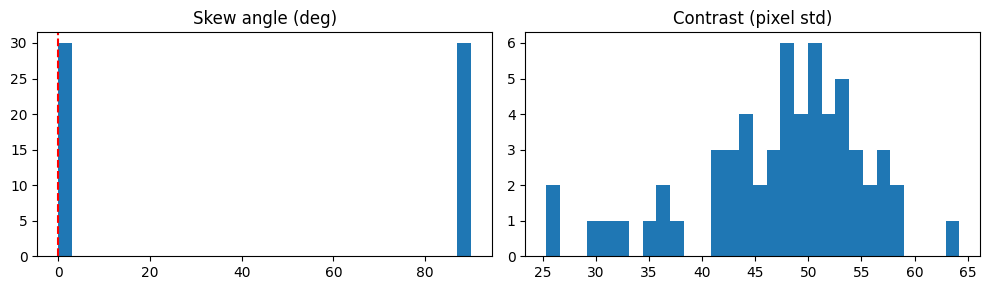

Sample 60 pages · median |skew| 44.75° · 36 pages beyond 0.5° (60%)
Contrast std: mean 47.4, min 25.3
=> If skew is near 0 and contrast is uniform, write "scans are clean; our difficulty is script, not degradation" and gate Stage 1 OUT.


In [13]:
import cv2

def skew_angle(png_path):
    """Estimate page rotation from the minimum-area rectangle around dark pixels."""
    img  = cv2.imread(str(png_path), cv2.IMREAD_GRAYSCALE)
    img  = cv2.resize(img, (0, 0), fx=0.3, fy=0.3)
    thr  = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]
    pts  = np.column_stack(np.where(thr > 0))
    if len(pts) < 100: return 0.0
    a = cv2.minAreaRect(pts.astype(np.float32))[-1]
    return float(a + 90 if a < -45 else a)

sample = random.Random(SEED).sample(todo, min(60, len(todo)))
angles = [skew_angle(p) for p in sample]
contr  = [float(np.asarray(Image.open(p).convert('L')).std()) for p in sample]

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].hist(angles, bins=30); ax[0].set_title('Skew angle (deg)'); ax[0].axvline(0, color='r', ls='--')
ax[1].hist(contr,  bins=30); ax[1].set_title('Contrast (pixel std)')
plt.tight_layout(); plt.savefig(FIGS / 'scan_quality.png', dpi=150); plt.show()

bad = sum(1 for a in angles if abs(a) > 0.5)
print(f'Sample {len(sample)} pages · median |skew| {np.median(np.abs(angles)):.2f}° · '
      f'{bad} pages beyond 0.5° ({100*bad/len(sample):.0f}%)')
print(f'Contrast std: mean {np.mean(contr):.1f}, min {np.min(contr):.1f}')
print('=> If skew is near 0 and contrast is uniform, write "scans are clean; our difficulty'
      ' is script, not degradation" and gate Stage 1 OUT.')


## 7 · Does 300 DPI actually help? (small ablation)

**Fills:** Section 2 → preparation table, *Rasterization* effect column.

Turns a default into a measured decision. Without ground-truth transcriptions we cannot
compute character error rate here, so we use two honest proxies: Tesseract's own mean
word confidence, and conjunct recovery rate (a blurred conjunct tends to lose its hasanta,
so hasanta count collapsing at low DPI is direct evidence of the failure we care about).

Real CER against `grading_kit/labels.jsonl` comes in §11, once pages are hand-transcribed.


In [ ]:
def confidence_and_conjuncts(pdf_path, page_no, dpi):
    doc = fitz.open(pdf_path)
    pix = doc[page_no].get_pixmap(dpi=dpi, colorspace=fitz.csGRAY)
    tmp = INTERIM / f'_dpi{dpi}.png'; pix.save(tmp); doc.close()
    d = pytesseract.image_to_data(Image.open(tmp), lang=OCR_LANG,
                                  config='--psm 6', output_type=pytesseract.Output.DICT)
    confs = [int(c) for c in d['conf'] if int(c) > 0]
    text  = normalise(' '.join(w for w in d['text'] if w.strip()))
    return (np.mean(confs) if confs else 0), text.count(HASANTA), len(text.split())

probe_book = RAW / BOOKS[0]['file']
probe_page = 60                                   # a body-text page, not front matter
if probe_book.exists():
    out = []
    for dpi in (150, 200, 300, 400):
        c, h, w = confidence_and_conjuncts(probe_book, probe_page, dpi)
        out.append({'dpi': dpi, 'mean_conf': round(c, 1), 'conjuncts': h, 'words': w})
    A = pd.DataFrame(out)
    display(A)
    print('Read this as: conjunct count collapsing at low DPI = fused glyphs being lost.')
    print(f'We rasterise at {DPI} because the gain flattens above it while cost keeps rising.')


## 8 · Assign every page to a chapter

**Fills:** Section 3 → *Data schema*; prerequisite for the split in §9.

The chapter is our split unit and our product's primary filter ("practise chapter 4"), so
every page needs a `chapter_id`. Two passes:

1. **Automatic** — match a chapter-heading pattern (অধ্যায়) in the OCR text; pages between
   two headings belong to the earlier one.
2. **Manual** — OCR misses headings on decorated chapter-opener pages, so we print the
   detected boundaries for eyeball verification and keep a hand-fix override.

Reporting the automatic-vs-manual ratio is itself a Section 2 preparation-table answer.


In [14]:
CH_PAT = re.compile(r'(প্রথম|দ্বিতীয়|তৃতীয়|চতুর্থ|পঞ্চম|ষষ্ঠ|সপ্তম|অষ্টম|নবম|দশম|একাদশ|দ্বাদশ|ত্রয়োদশ|চতুর্দশ)?\s*অধ্যায়')

detected = defaultdict(list)
for pid, txt in norm_texts.items():
    head = '\n'.join(txt.split('\n')[:6])       # headings live at the top
    if CH_PAT.search(head):
        book, pno = pid.split('_p')
        detected[book].append(int(pno))

for b in sorted(detected):
    print(f'{b}: {len(detected[b])} chapter-opener pages detected -> {sorted(detected[b])}')
print('\nCHECK BY HAND: does each book\'s count match its real chapter count?')
print('If low, OCR missed decorated openers — add them to MANUAL_STARTS below.')


bio: 31 chapter-opener pages detected -> [5, 6, 22, 23, 44, 55, 56, 69, 70, 81, 89, 90, 130, 131, 165, 166, 183, 184, 195, 196, 209, 210, 236, 237, 239, 259, 260, 287, 288, 310, 311]
chem: 18 chapter-opener pages detected -> [6, 22, 40, 41, 44, 59, 64, 70, 87, 95, 114, 147, 173, 211, 238, 266, 272, 292]
phy: 37 chapter-opener pages detected -> [6, 7, 37, 38, 49, 52, 56, 67, 68, 69, 81, 85, 103, 109, 132, 133, 134, 152, 164, 165, 191, 192, 193, 215, 216, 246, 247, 248, 260, 275, 276, 303, 304, 305, 334, 335, 351]

CHECK BY HAND: does each book's count match its real chapter count?
If low, OCR missed decorated openers — add them to MANUAL_STARTS below.


In [15]:
# Hand-fix layer. Fill after eyeballing the cell above; leave {} if detection was clean.
MANUAL_STARTS = {
    # 'phy': [9, 24, 41, ...],
    'phy' : [6,  37, 67, 103,  132,   164,  191,  215,  246, 275,  303,  334,  351],
    'bio' : [6, 22,55,  69, 89,  130,  165,  183,  195,  209,  236,  259,  287, 310],
    'chem' : [6, 22, 40, 64, 87,  114, 147, 173, 211, 238, 266,  292],
    
}

def chapter_map(book_id, n_pages):
    starts = sorted(set(MANUAL_STARTS.get(book_id, detected.get(book_id, []))))
    if not starts: starts = [1]
    bounds = starts + [n_pages + 1]
    m = {}
    for ci, (a, b) in enumerate(zip(bounds, bounds[1:]), start=1):
        for p in range(a, b):
            m[p] = f'{book_id}_ch{ci:02d}'
    for p in range(1, starts[0]):                 # front matter
        m[p] = f'{book_id}_front'
    return m

records = []
for b in BOOKS:
    n = len(page_paths.get(b['book_id'], []))
    if not n: continue
    cmap = chapter_map(b['book_id'], n)
    for p in range(1, n + 1):
        pid = f"{b['book_id']}_p{p:04d}"
        if pid not in norm_texts: continue        # blank/dropped
        records.append({
            'page_id'   : pid,
            'book_id'   : b['book_id'],
            'subject'   : b['subject'],
            'edition'   : b['edition'],
            'page_no'   : p,
            'chapter_id': cmap.get(p, f"{b['book_id']}_unk"),
            'n_words'   : words.get(pid, 0),
            'ink'       : round(ink.get(pid + '.png', 0), 4),
            'text'      : norm_texts[pid],
        })

P = pd.DataFrame(records)
P.drop(columns='text').to_csv(INTERIM / 'pages_meta.csv', index=False)
print(f'{len(P)} content pages across {P.chapter_id.nunique()} chapters')
display(P.groupby('subject').agg(pages=('page_id','count'),
                                 chapters=('chapter_id','nunique'),
                                 words=('n_words','sum')))


990 content pages across 42 chapters


,pages,chapters,words
subject,,,
biology,321,15,75819
chemistry,309,13,71825
physics,360,14,81739


## 9 · Stratified, seeded, chapter-level split

**Fills:** Section 2 → *How we split it*.

**Split unit: the chapter.** We train no model in the core build — OCR, embedder and LLM are
all pretrained. The split protects evaluation against *human* tuning: chunk size, top-k,
similarity threshold and prompt wording are all fitted by hand, and fitting them on the pages
we report scores on would make those scores measure memorisation.

**Chapter, not page** — NCTB chapters restate their own definitions in the summary
(সারসংক্ষেপ) and reuse terminology in the exercises (অনুশীলনী). Page-level splitting puts
near-duplicates on both sides. The chapter is the unit of correlation.

**Chapter, not whole book** — with three books, a book-level split makes test a single
subject. Biology is prose-heavy, Physics formula-heavy; a Biology-only test score would
overstate performance on exactly the pages our OCR finds hardest.

**Stratified** so each split holds all three subjects proportionally. **Seeded** and written
to `data/splits.json` so the partition is replayable — the auditability NFR applied to the
corpus itself.


In [16]:
def split_chapters(chapter_rows, ratios=RATIOS, seed=SEED):
    by_subj = defaultdict(list)
    for ch, subj in chapter_rows:
        by_subj[subj].append(ch)

    assign = {}
    for subj in sorted(by_subj):                  # sort => deterministic iteration
        chs = sorted(by_subj[subj])               # sort BEFORE shuffling, else seed is moot
        random.Random(seed).shuffle(chs)          # fresh RNG per subject: adding a chemistry
                                                  # chapter later must not reshuffle physics
        n = len(chs)
        n_tr = round(n * ratios['train'])
        n_va = max(1, round(n * ratios['val']))
        if n - n_tr - n_va < 1:                   # tiny-subject guard
            n_tr = n - n_va - 1
        for c in chs[:n_tr]:                assign[c] = 'train'
        for c in chs[n_tr:n_tr + n_va]:     assign[c] = 'val'
        for c in chs[n_tr + n_va:]:         assign[c] = 'test'
    return assign

# Front matter is excluded from all splits: it is not answerable content.
chap_rows = sorted({(r.chapter_id, r.subject) for r in P.itertuples()
                    if not r.chapter_id.endswith(('front', 'unk'))})
assignment = split_chapters(chap_rows)

(ROOT / 'data').mkdir(exist_ok=True)
(ROOT / 'data' / 'splits.json').write_text(json.dumps(
    {'seed': SEED, 'ratios': RATIOS, 'unit': 'chapter',
     'stratified_by': 'subject', 'assignment': assignment},
    indent=2, sort_keys=True, ensure_ascii=False))

P['split'] = P['chapter_id'].map(assignment)
S = P.dropna(subset=['split'])

tbl = S.groupby('split').agg(chapters=('chapter_id','nunique'),
                             pages=('page_id','count'),
                             words=('n_words','sum'))
tbl['%_pages'] = (100*tbl.pages/tbl.pages.sum()).round(1)
print('=== SECTION 2 SPLIT TABLE ===')
display(tbl.reindex(['train','val','test']))

print('\n=== Stratification proof: all subjects in every split ===')
display(S.pivot_table(index='subject', columns='split', values='chapter_id',
                      aggfunc='nunique', fill_value=0).reindex(columns=['train','val','test']))


=== SECTION 2 SPLIT TABLE ===


,chapters,pages,words,%_pages
split,,,,
train,27,653,152837,67.0
val,3,99,23957,10.2
test,9,223,51000,22.9



=== Stratification proof: all subjects in every split ===


split,train,val,test
subject,,,
biology,10,1,3
chemistry,8,1,3
physics,9,1,3


## 10 · Leakage checks

**Fills:** Section 2 → *The one way data could leak, and how we checked*.

Three checks, weakest to strongest. The form asks for the single most likely leak and proof
it did not happen — assertions that fail loudly are the proof.

1. **Disjointness** — no chapter in two splits (structural).
2. **Page uniqueness** — no page claimed by two chapters (catches boundary bugs in §8).
3. **Near-duplicate text across the boundary** — the real check. Chapter summaries restate
   chapter bodies almost verbatim; if a summary landed opposite its body we would be
   evaluating on content we had already read.

Check 3 uses character n-gram Jaccard rather than embeddings so this cell has no model
dependency and stays fast. The embedding-based version (max cosine similarity) runs in A2
once the index exists.


In [17]:
sets = {s: set(S[S.split==s].chapter_id) for s in ['train','val','test']}
assert not sets['train'] & sets['val'],  'train/val chapter overlap'
assert not sets['train'] & sets['test'], 'train/test chapter overlap'
assert not sets['val']   & sets['test'], 'val/test chapter overlap'
print(f"CHECK 1 PASS · {sum(len(v) for v in sets.values())} chapters, pairwise disjoint")

owner = {}
for r in S.itertuples():
    key = (r.book_id, r.page_no)
    assert key not in owner, f'page {key} claimed twice'
    owner[key] = r.split
print(f'CHECK 2 PASS · {len(owner)} pages, each in exactly one split')


CHECK 1 PASS · 39 chapters, pairwise disjoint
CHECK 2 PASS · 975 pages, each in exactly one split


In [18]:
def shingles(text, n=5):
    t = re.sub(r'\s+', ' ', text)
    return {t[i:i+n] for i in range(0, max(len(t)-n, 0), 2)}

def jaccard(a, b):
    return len(a & b) / len(a | b) if (a | b) else 0.0

chap_text = S.groupby('chapter_id')['text'].apply(' '.join)
sh = {c: shingles(t) for c, t in chap_text.items()}

pairs = [(a, b, jaccard(sh[a], sh[b]))
         for a in sets['test'] for b in sets['train']]
pairs.sort(key=lambda x: -x[2])

print('CHECK 3 · highest cross-split (test vs train) text similarity:')
display(pd.DataFrame(pairs[:5], columns=['test_chapter','train_chapter','jaccard']).round(3))

top = pairs[0][2] if pairs else 0
print(f'\nMax cross-split Jaccard = {top:.3f}')
print('Below ~0.35 => shared vocabulary only (expected: all three books are school science).'
      '\nAbove ~0.60 => inspect by hand; likely a chapter boundary error in section 8.')
assert top < 0.60, 'Suspicious cross-split near-duplicate — inspect before proceeding'


CHECK 3 · highest cross-split (test vs train) text similarity:


,test_chapter,train_chapter,jaccard
0,phy_ch02,phy_ch03,0.157
1,phy_ch11,phy_ch10,0.146
2,phy_ch02,phy_ch04,0.142
3,bio_ch02,bio_ch06,0.142
4,phy_ch11,phy_ch04,0.135



Max cross-split Jaccard = 0.157
Below ~0.35 => shared vocabulary only (expected: all three books are school science).
Above ~0.60 => inspect by hand; likely a chapter boundary error in section 8.


## 11 · Held-out pages for the grading kit

**Fills:** `grading_kit/heldout_pages/` + `labels.jsonl`, required by the submission structure.

These are pages you transcribe **by hand** so OCR accuracy can be measured against truth
rather than against Tesseract's own confidence. Sampling is seeded and drawn from the test
split only, and deliberately spans easy and hard pages — a held-out set of easy pages would
flatter the OCR score.

Licence note: these few page images are included as a small excerpt for non-commercial
academic evaluation, not as redistribution of the works (see `data/provenance.md`).


In [ ]:
import shutil
HELD = ROOT / 'grading_kit' / 'heldout_pages'
HELD.mkdir(parents=True, exist_ok=True)
N_HELD = 12

test_pages = S[S.split == 'test'].merge(
    D[['page_id','conjunct_rate','mixed_frac']], on='page_id', how='left')
test_pages['conjunct_rate'] = test_pages['conjunct_rate'].fillna(0)

# Half hardest-by-conjunct-density, half random: covers worst case and typical case.
hard = test_pages.nlargest(N_HELD // 2, 'conjunct_rate')
rest = test_pages[~test_pages.page_id.isin(hard.page_id)].sample(
    n=min(N_HELD // 2, len(test_pages) - len(hard)), random_state=SEED)
held = pd.concat([hard, rest])

with open(ROOT / 'grading_kit' / 'labels.jsonl', 'w', encoding='utf-8') as f:
    for r in held.itertuples():
        shutil.copy(PAGES / f'{r.page_id}.png', HELD / f'{r.page_id}.png')
        f.write(json.dumps({
            'page_id'    : r.page_id,
            'subject'    : r.subject,
            'chapter_id' : r.chapter_id,
            'page_no'    : int(r.page_no),
            'edition'    : r.edition,
            'ocr_text'   : r.text,      # machine output — REPLACE with hand transcription
            'gold_text'  : '',          # <-- TYPE THE TRUE TEXT HERE, by hand
        }, ensure_ascii=False) + '\n')

print(f'Wrote {len(held)} pages to grading_kit/heldout_pages/ + labels.jsonl')
print('ACTION REQUIRED: fill gold_text by hand. An empty gold_text makes CER unmeasurable,')
print('and the A2 autograder re-measures OCR against exactly this file.')


## 12 · Three findings and what each changes

**Fills:** Section 3 → *Findings* and *What this means for our build*.

A finding only earns marks if it changes a downstream decision. Each cell below prints the
number, then names the design consequence.


FINDING 1 — page length is uneven

  words/page: median 243 · p10 125 · p90 330
  pages under 60 words (figure/diagram-dominant): 8 (0.8%)


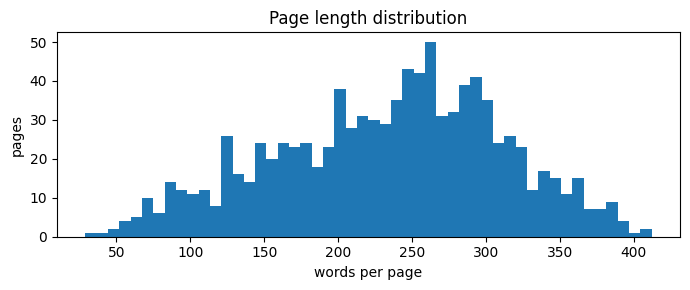


  CONSEQUENCE: fixed-size chunking would split dense pages mid-definition while
  emitting near-empty chunks from figure pages. We chunk on structure (heading /
  paragraph) with a minimum-length floor, and mark semantic chunking as our bonus.


In [19]:
print('FINDING 1 — page length is uneven\n')
w = S['n_words']
print(f'  words/page: median {w.median():.0f} · p10 {w.quantile(.1):.0f} · p90 {w.quantile(.9):.0f}')
print(f'  pages under 60 words (figure/diagram-dominant): {(w<60).sum()} ({100*(w<60).mean():.1f}%)')
plt.figure(figsize=(7,3)); plt.hist(w, bins=50)
plt.xlabel('words per page'); plt.ylabel('pages'); plt.title('Page length distribution')
plt.tight_layout(); plt.savefig(FIGS/'page_length.png', dpi=150); plt.show()
print('\n  CONSEQUENCE: fixed-size chunking would split dense pages mid-definition while')
print('  emitting near-empty chunks from figure pages. We chunk on structure (heading /')
print('  paragraph) with a minimum-length floor, and mark semantic chunking as our bonus.')


In [20]:
print('FINDING 2 — conjunct density varies sharply by subject\n')
display(D.groupby('book')['conjunct_rate'].mean().round(4))
print(f"\n  Code-mixed pages: {(D['mixed_lines']>0).sum()} of {len(D)} "
      f"({100*(D['mixed_lines']>0).mean():.0f}%)")
print('\n  CONSEQUENCE: a single global OCR score would hide where we fail. We report')
print('  character-level CER per subject, and run ben+eng on pages flagged code-mixed')
print('  rather than forcing one language mode across the whole corpus.')


FINDING 2 — conjunct density varies sharply by subject



book
bio     0.0748
chem    0.0685
phy     0.0670
Name: conjunct_rate, dtype: float64


  Code-mixed pages: 971 of 987 (98%)

  CONSEQUENCE: a single global OCR score would hide where we fail. We report
  character-level CER per subject, and run ben+eng on pages flagged code-mixed
  rather than forcing one language mode across the whole corpus.


In [21]:
print('FINDING 3 — a real share of pages are figure-dominant\n')
lowtext = S[(S.n_words < 60) & (S.ink > 0.02)]      # little text, plenty of ink => figures
print(f'  {len(lowtext)} pages ({100*len(lowtext)/len(S):.1f}%) carry ink but almost no OCR text')
display(lowtext.groupby('subject').size().rename('figure_dominant_pages'))
print('\n  CONSEQUENCE: these pages carry Bangla labels *inside* diagrams that flat OCR')
print('  misses, so Stage 2 (layout) is CORE for us, not optional. It also means some')
print('  student questions are unanswerable from text alone — an honest abstention case.')


FINDING 3 — a real share of pages are figure-dominant

  6 pages (0.6%) carry ink but almost no OCR text


subject
biology      3
chemistry    1
physics      2
Name: figure_dominant_pages, dtype: int64


  CONSEQUENCE: these pages carry Bangla labels *inside* diagrams that flat OCR
  misses, so Stage 2 (layout) is CORE for us, not optional. It also means some
  student questions are unanswerable from text alone — an honest abstention case.


## 13 · Three real example pages

**Fills:** Section 3 → *Three example pages* (page id · scan-quality note · extracted text).

The form warns that generic images score zero. These are rendered from our own corpus and
saved to `reports/figures/` so they can be pasted straight into the form.

We pick deliberately: the cleanest page, the most conjunct-dense page, and a
figure-dominant page — best case, hardest case, and the case that motivates the layout stage.


In [ ]:
cand = S.merge(D[['page_id','conjunct_rate','mixed_frac']], on='page_id', how='left')
cand['conjunct_rate'] = cand['conjunct_rate'].fillna(0)

picks = [
    ('typical, clean body text', cand[cand.n_words > cand.n_words.median()].nsmallest(1,'conjunct_rate')),
    ('hardest — conjunct-dense', cand.nlargest(1, 'conjunct_rate')),
    ('figure-dominant',          cand[cand.ink > 0.02].nsmallest(1, 'n_words')),
]

for note, row in picks:
    if row.empty: continue
    r = row.iloc[0]
    src = PAGES / f'{r.page_id}.png'
    shutil.copy(src, FIGS / f'example_{r.page_id}.png')
    print('=' * 78)
    print(f'PAGE ID    : {r.page_id}   ({r.subject}, {r.chapter_id}, p.{r.page_no}, ed. {r.edition})')
    print(f'QUALITY    : {note} · ink {r.ink:.3f} · {r.n_words} words · '
          f'conjunct rate {r.conjunct_rate:.4f}')
    print(f'EXTRACTED  : {r.text[:260]}...')
    display(Image.open(src).resize((440, 620)))


## 14 · Data schema

**Fills:** Section 3 → *Data schema* table (field · type · meaning · typical value).

Page-level fields are what this notebook produces. Chunk-level fields are what A2 will add;
they are declared now because the schema is the contract between milestones — Section 4 of
the A2 form asks what must not change, and this is that answer.


In [ ]:
schema = [
 ('page_id',    'string','unique page key',                      'phy_p0187','page'),
 ('book_id',    'string','which volume',                         'phy','page'),
 ('subject',    'string','physics | chemistry | biology',         'physics','page'),
 ('edition',    'string','pinned NCTB revision — citations are page-anchored','2025-10','page'),
 ('page_no',    'int',   'page number within the volume',         '187','page'),
 ('chapter_id', 'string','chapter — our split unit and product filter','phy_ch11','page'),
 ('n_words',    'int',   'post-OCR usable words',                 '212','page'),
 ('ink',        'float', 'dark-pixel fraction; blank detection',  '0.081','page'),
 ('split',      'string','train | val | test',                    'train','page'),
 ('text',       'string','normalised OCR text (NFC, ZW* stripped)','পরিবাহীর মধ্য দিয়ে...','page'),
 ('chunk_id',   'string','unique chunk key',                      'phy_ch11_c007','chunk (A2)'),
 ('chunk_type', 'string','concept | worked_example | exercise_q', 'concept','chunk (A2)'),
 ('question_id','string','links an exercise answer to its question','phy_ch11_q07','chunk (A2)'),
 ('embedding',  'float[]','vector for retrieval',                 '[0.013, -0.221, ...]','chunk (A2)'),
]
display(pd.DataFrame(schema, columns=['field','type','meaning','typical value','level']))


## 15 · Form summary — every number in one place

Run this last and copy straight into the A1 form. Also written to
`reports/a1_numbers.json` so the form and the notebook cannot drift apart.


In [ ]:
summary = {
 'books'              : len(sizes),
 'total_pages_raw'    : int(sizes.pages.sum()),
 'blank_pages_removed': len(blanks),
 'content_pages'      : int(len(S)),
 'total_words'        : int(S.n_words.sum()),
 'mean_words_page'    : round(float(S.n_words.mean()), 1),
 'disk_pdf_MB'        : float(sizes.MB.sum()),
 'disk_png_MB'        : round(png_mb, 1),
 'chapters'           : int(S.chapter_id.nunique()),
 'split_pages'        : S.groupby('split').size().to_dict(),
 'split_pct'          : (100*S.groupby('split').size()/len(S)).round(1).to_dict(),
 'max_cross_split_jaccard': round(float(top), 3),
 'mean_conjunct_rate' : round(float(D.conjunct_rate.mean()), 4),
 'pct_pages_code_mixed': round(float(100*(D.mixed_lines>0).mean()), 1),
 'median_abs_skew_deg': round(float(np.median(np.abs(angles))), 2),
 'dpi'                : DPI, 'ocr_lang': OCR_LANG, 'seed': SEED,
}
(ROOT/'reports').mkdir(exist_ok=True)
(ROOT/'reports'/'a1_numbers.json').write_text(json.dumps(summary, indent=2))

print('=' * 60); print('A1 FORM NUMBERS'); print('=' * 60)
for k, v in summary.items(): print(f'{k:26s}: {v}')
print('=' * 60)
print(f"Page floor >=300 : {'PASS' if summary['content_pages']>=300 else 'FAIL'}")
print(f"Word floor >=60k : {'PASS' if summary['total_words']>=60000 else 'FAIL'}")
